# Practice 13 — RNN for Time Series

A recurrent network reads five consecutive trading days and predicts the closing index of the next one.

Two models share one recurrent layer and differ only in what their linear readout is allowed to read.

| Model | Readout input |
|:---|:---|
| A | the last hidden state |
| B | all hidden states, laid end to end |

**Dataset.** KOSPI daily quotes, 431 trading days from 2019-01-30 to 2020-10-30.

| Step | What it produces |
|:---|:---|
| Windows | the input tensor and the next-day target |
| Split | chronological train / validation / test, standardized on training statistics |
| `train` / `evaluate` | the epoch loop and the no-grad pass |
| Comparison | learning curves, predictions in index points, RMSE |

---
## Step 0. Imports and Setup

In [1]:
import math
import os
import urllib.request

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


---
## Step 1. The Series

Daily KOSPI quotes, one row per trading day.

| Column | Use |
|:---|:---|
| `Open`, `High`, `Low`, `Volume` | model input |
| `Close` | prediction target |
| `Date`, `Adj Close` | not used |

In [2]:
DATA_PATH = './data/kospi.csv'
DATA_URL = 'https://raw.githubusercontent.com/jongmoonha/AI-ME-Practice/main/data/kospi.csv'

if not os.path.exists(DATA_PATH):
    os.makedirs('./data', exist_ok=True)
    print('downloading kospi.csv ...')
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

df = pd.read_csv(DATA_PATH)

first_date = df['Date'].iloc[0]
last_date = df['Date'].iloc[-1]
print(f'rows: {len(df)}, from {first_date} to {last_date}')
print(f'missing values: {df.isna().sum().sum()}')

df.head(10)

rows: 431, from 2019-01-30 to 2020-10-30
missing values: 0


,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-01-30,2183.489990,2206.199951,2177.879883,2206.199951,2206.199951,480400
1,2019-01-31,2222.879883,2222.879883,2201.219971,2204.850098,2204.850098,545200
2,2019-02-01,2211.929932,2218.780029,2201.409912,2203.459961,2203.459961,479400
3,2019-02-07,2215.770020,2215.790039,2196.770020,2203.419922,2203.419922,427800
4,2019-02-08,2192.010010,2192.479980,2171.959961,2177.050049,2177.050049,391000
5,2019-02-11,2180.540039,2181.580078,2167.360107,2180.729980,2180.729980,406100
6,2019-02-12,2182.709961,2195.050049,2178.590088,2190.469971,2190.469971,429900
7,2019-02-13,2200.000000,2203.709961,2194.750000,2201.479980,2201.479980,422000
8,2019-02-14,2195.919922,2225.850098,2186.090088,2225.850098,2225.850098,573400
9,2019-02-15,2210.939941,2210.939941,2187.709961,2196.090088,2196.090088,400600


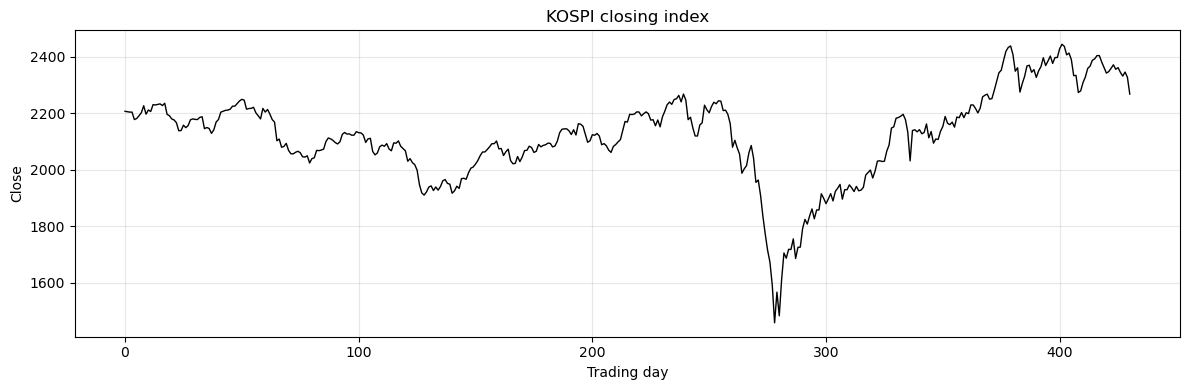

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(df['Close'].values, 'k-', linewidth=1)
ax.set_xlabel('Trading day')
ax.set_ylabel('Close')
ax.set_title('KOSPI closing index')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## Step 2. Sliding Windows

The model reads a window of $T$ consecutive days and predicts the `Close` of the day that follows it.

| Tensor | Shape | Meaning |
|:---|:---|:---|
| `X_seq` | $(N, T, d)$ | $N$ windows of $T$ days, $d$ features per day |
| `y_seq` | $(N, 1)$ | the `Close` of the day after each window |

With $T = 5$ and 431 trading days the series yields $N = 431 - 5 = 426$ windows.

Each window overlaps its neighbour by four days, so consecutive windows are far from independent.

In [4]:
sequence_length = 5

X_all = df[['Open', 'High', 'Low', 'Volume']].values.astype(np.float32)
y_all = df[['Close']].values.astype(np.float32)


def to_sequences(X, y, sequence_length):
    # window i covers days i .. i+sequence_length-1 and targets the Close of day i+sequence_length
    X_windows = []
    y_targets = []
    for i in range(len(X) - sequence_length):
        X_windows.append(X[i:i + sequence_length])
        y_targets.append(y[i + sequence_length])
    return np.array(X_windows), np.array(y_targets)


X_seq, y_seq = to_sequences(X_all, y_all, sequence_length)

print(f'X_seq {tuple(X_seq.shape)}   (N, T, d)')
print(f'y_seq {tuple(y_seq.shape)}   (N, 1)')

X_seq (426, 5, 4)   (N, T, d)
y_seq (426, 1)   (N, 1)


---
## Step 3. Chronological Split and Scaling

A shuffled split would drop later days into the training set and let the model interpolate between days it
has already been shown.
Cutting the windows in time order keeps every validation and test window after every training window.

| Split | Windows | Share |
|:---|:---|:---|
| Train | 298 | 70% |
| Validation | 63 | 15% |
| Test | 65 | 15% |

The standardization statistics are computed on the training windows alone and then applied to all three
splits.

Four loaders over three splits.
`train_loader` shuffles because the update order should not follow the calendar, while `train_eval_loader`
holds the same windows in time order so the predictions can be drawn as a curve.

| Loader | Windows | `shuffle` | Used for |
|:---|:---|:---|:---|
| `train_loader` | train | `True` | the update loop |
| `train_eval_loader` | train | `False` | predictions in time order |
| `val_loader` | validation | `False` | monitoring after each epoch |
| `test_loader` | test | `False` | read once, at the end |

In [5]:
n_train = int(len(X_seq) * 0.70)
n_val = int(len(X_seq) * 0.15)

X_train, y_train = X_seq[:n_train], y_seq[:n_train]
X_val, y_val = X_seq[n_train:n_train + n_val], y_seq[n_train:n_train + n_val]
X_test, y_test = X_seq[n_train + n_val:], y_seq[n_train + n_val:]

input_size = X_seq.shape[2]

# every day inside a training window counts once, so the windows are flattened before averaging
input_train_mean = X_train.reshape(-1, input_size).mean(axis=0)
input_train_std = X_train.reshape(-1, input_size).std(axis=0)
input_train_std[input_train_std == 0] = 1.0   # leave zero-variance features unscaled

close_train_mean = y_train.mean()
close_train_std = y_train.std()

X_train = (X_train - input_train_mean) / input_train_std
X_val = (X_val - input_train_mean) / input_train_std
X_test = (X_test - input_train_mean) / input_train_std

y_train = (y_train - close_train_mean) / close_train_std
y_val = (y_val - close_train_mean) / close_train_std
y_test = (y_test - close_train_mean) / close_train_std

print(f'windows - train {len(X_train)}, val {len(X_val)}, test {len(X_test)}')
print(f'close_train_mean {close_train_mean:.2f}, close_train_std {close_train_std:.2f}')
print(f'standardized target range - train [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'standardized target range - val   [{y_val.min():.3f}, {y_val.max():.3f}]')
print(f'standardized target range - test  [{y_test.min():.3f}, {y_test.max():.3f}]')
print(f'test windows above the training maximum: {(y_test > y_train.max()).sum()} of {len(y_test)}')

batch_size = 20

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

train_set = TensorDataset(X_train_tensor, y_train_tensor)
val_set = TensorDataset(X_val_tensor, y_val_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
train_eval_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f'batches per epoch - train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}')

X_batch, y_batch = next(iter(train_loader))
print(f'one batch - X {tuple(X_batch.shape)}, y {tuple(y_batch.shape)}')

windows - train 298, val 63, test 65
close_train_mean 2077.65, close_train_std 140.46
standardized target range - train [-4.414, 1.350]
standardized target range - val   [-1.343, 1.076]
standardized target range - test  [0.998, 2.605]
test windows above the training maximum: 58 of 65
batches per epoch - train 15, val 4, test 4
one batch - X (20, 5, 4), y (20, 1)


---
## Step 4. What a Recurrent Layer Computes

The layer carries a hidden state $\mathbf{h}_t \in \mathbb{R}^{H}$ and rewrites it once per time step.

$$\mathbf{h}_t = \tanh\!\left(\mathbf{W}_{xh}\mathbf{x}_t + \mathbf{b}_{xh}
+ \mathbf{W}_{hh}\mathbf{h}_{t-1} + \mathbf{b}_{hh}\right),
\qquad t = 1, \dots, T, \qquad \mathbf{h}_0 = \mathbf{0}$$

The same two matrices are reused at every step, which is what makes the layer recurrent.

| Symbol | Shape | Parameter |
|:---|:---|:---|
| $\mathbf{W}_{xh}$ | $(H, d)$ | `weight_ih_l0` |
| $\mathbf{W}_{hh}$ | $(H, H)$ | `weight_hh_l0` |
| $\mathbf{b}_{xh}$, $\mathbf{b}_{hh}$ | $(H,)$ each | `bias_ih_l0`, `bias_hh_l0` |

A textbook writes one bias where PyTorch keeps two; the unrolled loop below adds both.

In [6]:
hidden_size = 8
num_layers = 1

torch.manual_seed(42)
demo_rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

X_window = X_train_tensor[0:1]                          # a single window, (1, T, d)
h0 = torch.zeros(num_layers, 1, hidden_size)            # the initial hidden state is all zeros

with torch.no_grad():
    out, h_n = demo_rnn(X_window, h0)

# the same recurrence written out one time step at a time
weight_ih = demo_rnn.weight_ih_l0
weight_hh = demo_rnn.weight_hh_l0
bias_ih = demo_rnn.bias_ih_l0
bias_hh = demo_rnn.bias_hh_l0

h = torch.zeros(hidden_size)
with torch.no_grad():
    for t in range(sequence_length):
        x_t = X_window[0, t]
        h = torch.tanh(weight_ih @ x_t + bias_ih + weight_hh @ h + bias_hh)

print(f'out {tuple(out.shape)} holds h_1 .. h_T, h_n {tuple(h_n.shape)} holds h_T alone')
print('by hand :', h.numpy())
print('nn.RNN  :', out[0, -1].numpy())

out (1, 5, 8) holds h_1 .. h_T, h_n (1, 1, 8) holds h_T alone
by hand : [ 0.5033927  -0.50471514 -0.09632248  0.00760593 -0.31598416 -0.35692045
  0.10617422 -0.13799968]
nn.RNN  : [ 0.5033927  -0.50471514 -0.09632247  0.0076059  -0.31598416 -0.35692045
  0.10617425 -0.13799976]


---
## Step 5. `train` and `evaluate`

| Function | Returns |
|:---|:---|
| `evaluate(model, loader, device)` | `(loss, rmse, y_pred)` |
| `train(model, train_loader, val_loader, optimizer, epochs, device)` | `(train_losses, train_rmses, val_losses, val_rmses)` |

`loss` averages one mean squared error per batch, which is what the learning curves plot, and `rmse` is
its square root in index points.
The last batch of a split is shorter than the others, so Step 8 recomputes the reported figures from
`y_pred` over each split as a whole.

Monitoring runs on `val_loader`; `test_loader` inside the loop would let the test set steer the choice
between the two models.

In [7]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.MSELoss()
    loss_sum = 0.0
    preds = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_hat = model(X_batch)
            loss_sum += criterion(y_hat, y_batch).item()
            preds.append(y_hat.cpu())

    loss = loss_sum / len(loader)
    rmse = math.sqrt(loss) * close_train_std      # standardized error back into index points
    y_pred = torch.cat(preds).numpy()
    return loss, rmse, y_pred

In [8]:
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.MSELoss()
    train_losses, train_rmses, val_losses, val_rmses = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)

            optimizer.zero_grad()                 # clear the accumulated gradients
            loss.backward()                       # autograd computes the gradients
            optimizer.step()                      # the optimizer updates the parameters

            loss_sum += loss.item()

        train_loss = loss_sum / len(train_loader)
        val_loss, val_rmse, _ = evaluate(model, val_loader, device)

        train_losses.append(train_loss)
        train_rmses.append(math.sqrt(train_loss) * close_train_std)
        val_losses.append(val_loss)
        val_rmses.append(val_rmse)

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'train MSE={train_loss:.5f}  val MSE={val_loss:.5f}  '
                  f'val RMSE={val_rmse:.1f} points')
    return train_losses, train_rmses, val_losses, val_rmses

In [9]:
rho = 1e-3
epochs = 200

print(f'Sequence length : {sequence_length}')
print(f'Hidden size     : {hidden_size}')
print(f'Recurrent layers: {num_layers}')
print(f'Batch size      : {batch_size}')
print(f'Learning rate   : {rho}')
print(f'Epochs          : {epochs}')
print(f'Optimizer       : Adam')
print(f'Loss            : {nn.MSELoss()}')

Sequence length : 5
Hidden size     : 8
Recurrent layers: 1
Batch size      : 20
Learning rate   : 0.001
Epochs          : 200
Optimizer       : Adam
Loss            : MSELoss()


---
## Step 6. Model A — Last Hidden State

The readout sees only the final hidden state.

$$\hat{y} = \mathbf{w}^{\top}\mathbf{h}_T + b, \qquad \mathbf{w} \in \mathbb{R}^{H}$$

$\mathbf{h}_T$ is the state after the layer has read all $T$ days, so the earlier days reach the readout
only through what the recurrence carried forward.

In [10]:
class RNNLastState(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, h_n = self.rnn(x, h0)      # out holds h_1 .. h_T for every window in the batch
        y_hat = self.fc(out[:, -1, :])  # the last time step only
        return y_hat

In [11]:
torch.manual_seed(42)
model_last_state = RNNLastState(input_size, hidden_size, num_layers).to(device)
optimizer_last_state = optim.Adam(model_last_state.parameters(), lr=rho)

torch.manual_seed(42)   # train_loader shuffles from the same state for both models
print('Model A (last hidden state)')
train_losses_last_state, train_rmses_last_state, val_losses_last_state, val_rmses_last_state = train(
    model_last_state, train_loader, val_loader, optimizer_last_state, epochs, device)

Model A (last hidden state)


  Epoch  50/200  train MSE=0.05390  val MSE=0.04395  val RMSE=29.4 points


  Epoch 100/200  train MSE=0.03985  val MSE=0.03116  val RMSE=24.8 points


  Epoch 150/200  train MSE=0.03636  val MSE=0.03243  val RMSE=25.3 points


  Epoch 200/200  train MSE=0.03303  val MSE=0.03102  val RMSE=24.7 points


---
## Step 7. Model B — All Hidden States

The readout sees every hidden state, laid end to end.

$$\hat{y} = \mathbf{w}^{\top}\left[\mathbf{h}_1; \mathbf{h}_2; \dots; \mathbf{h}_T\right] + b,
\qquad \mathbf{w} \in \mathbb{R}^{HT}$$

The recurrent layer is untouched, so the only thing that changes is what the linear layer is allowed to
read.

In [12]:
class RNNAllStates(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, sequence_length):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size * sequence_length, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, h_n = self.rnn(x, h0)             # out holds h_1 .. h_T for every window in the batch
        y_hat = self.fc(out.reshape(out.size(0), -1))   # all time steps, laid end to end
        return y_hat

In [13]:
torch.manual_seed(42)
model_all_states = RNNAllStates(input_size, hidden_size, num_layers, sequence_length).to(device)
optimizer_all_states = optim.Adam(model_all_states.parameters(), lr=rho)

torch.manual_seed(42)   # train_loader shuffles from the same state for both models
print('Model B (all hidden states)')
train_losses_all_states, train_rmses_all_states, val_losses_all_states, val_rmses_all_states = train(
    model_all_states, train_loader, val_loader, optimizer_all_states, epochs, device)

Model B (all hidden states)


  Epoch  50/200  train MSE=0.05476  val MSE=0.05509  val RMSE=33.0 points


  Epoch 100/200  train MSE=0.04100  val MSE=0.04961  val RMSE=31.3 points


  Epoch 150/200  train MSE=0.03593  val MSE=0.05468  val RMSE=32.8 points


  Epoch 200/200  train MSE=0.03258  val MSE=0.05212  val RMSE=32.1 points


---
## Step 8. Comparison

| Item | A (last state) | B (all states) |
|:---|:---|:---|
| Readout input | `out[:, -1, :]` | `out.reshape(out.size(0), -1)` |
| Readout layer | `nn.Linear(hidden_size, 1)` | `nn.Linear(hidden_size * sequence_length, 1)` |
| Recurrent layer | `nn.RNN`, $H = 8$, one layer, $\tanh$ | same |
| Data, split, scaling, loaders | shared objects from Step 3 | same |
| $\rho$, epochs, batch size, optimizer, loss | shared values from Step 5 | same |
| Seed before construction and before training | 42 | 42 |

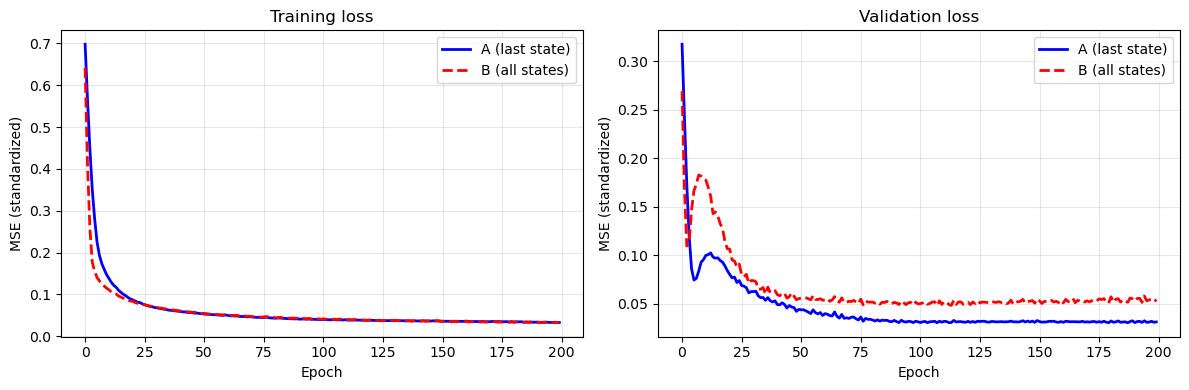

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses_last_state, 'b-', linewidth=2, label='A (last state)')
axes[0].plot(train_losses_all_states, 'r--', linewidth=2, label='B (all states)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (standardized)')
axes[0].set_title('Training loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(val_losses_last_state, 'b-', linewidth=2, label='A (last state)')
axes[1].plot(val_losses_all_states, 'r--', linewidth=2, label='B (all states)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (standardized)')
axes[1].set_title('Validation loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

The readout of B carries $HT + 1 = 41$ weights against $H + 1 = 9$ in A.
That is a consequence of what B reads, not a second change on top of it.

The test window is mostly an extrapolation.
Step 3 counted 58 of its 65 targets above the training maximum of 1.350, so both prediction curves sit
below the actual line there.
The validation targets stay inside the training range.

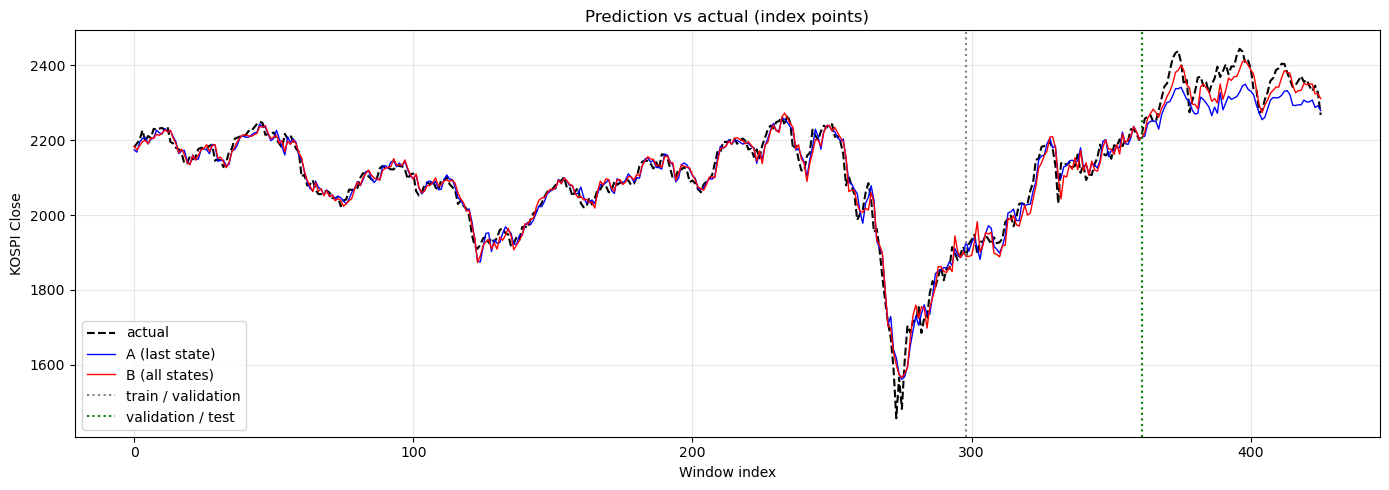

In [15]:
_, _, y_pred_train_last_state = evaluate(model_last_state, train_eval_loader, device)
_, _, y_pred_val_last_state = evaluate(model_last_state, val_loader, device)
_, _, y_pred_test_last_state = evaluate(model_last_state, test_loader, device)

_, _, y_pred_train_all_states = evaluate(model_all_states, train_eval_loader, device)
_, _, y_pred_val_all_states = evaluate(model_all_states, val_loader, device)
_, _, y_pred_test_all_states = evaluate(model_all_states, test_loader, device)

# the three splits are already in time order, so concatenating them rebuilds the whole series
y_pred_last_state = np.concatenate(
    [y_pred_train_last_state, y_pred_val_last_state, y_pred_test_last_state])
y_pred_all_states = np.concatenate(
    [y_pred_train_all_states, y_pred_val_all_states, y_pred_test_all_states])

close_pred_last_state = y_pred_last_state[:, 0] * close_train_std + close_train_mean
close_pred_all_states = y_pred_all_states[:, 0] * close_train_std + close_train_mean
close_actual = y_seq[:, 0]      # y_seq was never standardized, so it is still in index points

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(close_actual, 'k--', linewidth=1.5, label='actual')
ax.plot(close_pred_last_state, 'b-', linewidth=1, label='A (last state)')
ax.plot(close_pred_all_states, 'r-', linewidth=1, label='B (all states)')
ax.axvline(n_train, color='gray', linestyle=':', label='train / validation')
ax.axvline(n_train + n_val, color='green', linestyle=':', label='validation / test')

ax.set_xlabel('Window index'); ax.set_ylabel('KOSPI Close')
ax.set_title('Prediction vs actual (index points)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [16]:
# RMSE over each split as a whole
train_rmse_last_state = math.sqrt(((y_pred_train_last_state - y_train) ** 2).mean())
val_rmse_last_state = math.sqrt(((y_pred_val_last_state - y_val) ** 2).mean())
test_rmse_last_state = math.sqrt(((y_pred_test_last_state - y_test) ** 2).mean())

train_rmse_all_states = math.sqrt(((y_pred_train_all_states - y_train) ** 2).mean())
val_rmse_all_states = math.sqrt(((y_pred_val_all_states - y_val) ** 2).mean())
test_rmse_all_states = math.sqrt(((y_pred_test_all_states - y_test) ** 2).mean())

print('RMSE on standardized targets, with the same error in index points in brackets')
print(f'Model A (last state)  '
      f'train {train_rmse_last_state:.4f} [{train_rmse_last_state * close_train_std:6.1f}]  '
      f'val {val_rmse_last_state:.4f} [{val_rmse_last_state * close_train_std:6.1f}]  '
      f'test {test_rmse_last_state:.4f} [{test_rmse_last_state * close_train_std:6.1f}]')
print(f'Model B (all states)  '
      f'train {train_rmse_all_states:.4f} [{train_rmse_all_states * close_train_std:6.1f}]  '
      f'val {val_rmse_all_states:.4f} [{val_rmse_all_states * close_train_std:6.1f}]  '
      f'test {test_rmse_all_states:.4f} [{test_rmse_all_states * close_train_std:6.1f}]')

RMSE on standardized targets, with the same error in index points in brackets
Model A (last state)  train 0.1796 [  25.2]  val 0.1971 [  27.7]  test 0.4544 [  63.8]
Model B (all states)  train 0.1782 [  25.0]  val 0.2564 [  36.0]  test 0.2613 [  36.7]


The validation column is where the two readouts can be compared, because it is the only held-out stretch
that stays inside the range the models were fitted on.
The test column measures something else: how far the forecast drifts once the series leaves that range.

---
## Summary

- A recurrent layer keeps one hidden state and reuses the same two weight matrices at every step,
  so window length leaves its parameter count unchanged — only the readout of B grows with it.
- The two models shared the recurrent layer, the loaders and every hyperparameter.
  What separates their curves is the readout input.
- Errors are reported in index points as well as standardized units, because a standardized RMSE says
  nothing about the size of the miss.

---
## Exercises

1. Set `num_layers` to 2 in both classes and retrain.
   Both classes read the same variable.
2. Set `sequence_length` to 40 and rerun from Step 2.
   Report what happens to the training loss.
3. Add `Close` to the input columns and retrain.
   Does yesterday's level change the test error?
4. Predict the day-to-day change in `Close` instead of its level.

In [17]:
# Write your code here